This notebook demonstrates the TextCNN workflow (preprocessing, model, training, evaluation, experiments) end-to-end in Google Colab (GPU). Numbers here may differ slightly from the official results in results/textcnn/, which come from a training run on CPU (see history.json, test_metrics.json). Both runs are within about 1 point of each other, showing the model is stable across hardware.

In [1]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 74.9 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving labels.json to labels.json
Saving test.csv to test.csv
Saving train.csv to train.csv
Saving val.csv to val.csv


In [3]:
import json, re
from collections import Counter

import numpy as np
import pandas as pd
import torch

MAX_LEN = 50
MIN_FREQ = 2
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
GLOVE_NAME = "glove-wiki-gigaword-100"
EMBED_DIM = 100
SEED = 42


def tokenize(text):
    return re.findall(r"[a-z0-9']+", text.lower())


def build_vocab(train_texts):
    counter = Counter()
    for text in train_texts:
        counter.update(tokenize(text))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.most_common():
        if freq >= MIN_FREQ:
            vocab[word] = len(vocab)
    return vocab


def encode(text, vocab, max_len=MAX_LEN):
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokenize(text)]
    ids = ids[:max_len]
    return ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))


def encode_batch(texts, vocab, max_len=MAX_LEN):
    return torch.tensor([encode(t, vocab, max_len) for t in texts], dtype=torch.long)


def build_embedding_matrix(vocab):
    import gensim.downloader as api
    glove = api.load(GLOVE_NAME)
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0, 0.1, size=(len(vocab), EMBED_DIM)).astype("float32")
    matrix[vocab[PAD_TOKEN]] = 0.0
    found = 0
    for word, idx in vocab.items():
        if word in glove:
            matrix[idx] = glove[word]
            found += 1
    return torch.from_numpy(matrix), found


# ---- run it ----
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")
test = pd.read_csv("test.csv")

vocab = build_vocab(train["text"].tolist())
print(f"Vocabulary size: {len(vocab)}")

example = train["text"].iloc[0]
print(f"\nExample: {example}")
print(f"Tokens:  {tokenize(example)}")
print(f"Encoded: {encode(example, vocab)[:15]} ... (first 15 of {MAX_LEN})")

X_train = encode_batch(train["text"], vocab)
X_val = encode_batch(val["text"], vocab)
X_test = encode_batch(test["text"], vocab)
print(f"\nX_train shape: {tuple(X_train.shape)}")
print(f"X_val shape:   {tuple(X_val.shape)}")
print(f"X_test shape:  {tuple(X_test.shape)}")

matrix, found = build_embedding_matrix(vocab)
print(f"\nEmbedding matrix shape: {tuple(matrix.shape)}")
print(f"Words found in GloVe: {found} of {len(vocab)} ({found / len(vocab):.1%})")

Vocabulary size: 1455

Example: For adding money, which currencies do you accept?
Tokens:  ['for', 'adding', 'money', 'which', 'currencies', 'do', 'you', 'accept']
Encoded: [12, 445, 20, 159, 117, 10, 18, 213, 0, 0, 0, 0, 0, 0, 0] ... (first 15 of 50)

X_train shape: (9002, 50)
X_val shape:   (1001, 50)
X_test shape:  (3080, 50)
[==================================================] 100.0% 128.1/128.1MB downloaded

Embedding matrix shape: (1455, 100)
Words found in GloVe: 1408 of 1455 (96.8%)


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TextCNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 100,
        num_classes: int = 77,
        kernel_sizes: tuple = (2, 3, 4),
        num_filters: int = 100,
        dropout: float = 0.5,
        pad_idx: int = 0,
        pretrained: torch.Tensor = None,
        freeze_embeddings: bool = False,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if pretrained is not None:
            self.embedding.weight.data.copy_(pretrained)  # start from GloVe
        self.embedding.weight.requires_grad = not freeze_embeddings

        # One Conv1d per window size. Each looks at k neighbouring words.
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, kernel_size=k) for k in kernel_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        # x: (batch, seq_len) word ids
        emb = self.embedding(x)          # (batch, seq_len, embed_dim)
        emb = emb.transpose(1, 2)        # Conv1d wants (batch, embed_dim, seq_len)

        pooled = []
        for conv in self.convs:
            h = F.relu(conv(emb))                 # (batch, num_filters, seq_len - k + 1)
            p = F.max_pool1d(h, h.size(2))        # strongest match per filter
            pooled.append(p.squeeze(2))           # (batch, num_filters)

        features = torch.cat(pooled, dim=1)       # (batch, num_filters * n_kernels)
        return self.fc(self.dropout(features))    # (batch, num_classes) raw scores


def count_parameters(model: nn.Module) -> int:
    """Number of trainable parameters (used in the model comparison)."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


if __name__ == "__main__":
    torch.manual_seed(42)
    model = TextCNN(vocab_size=1455, pretrained=torch.randn(1455, 100))
    print(model)
    print(f"\nTrainable parameters: {count_parameters(model):,}")

    fake_batch = torch.randint(0, 1455, (8, 50))  # 8 fake sentences of 50 ids
    out = model(fake_batch)
    print(f"Input shape:  {tuple(fake_batch.shape)}")
    print(f"Output shape: {tuple(out.shape)}  (expected (8, 77))")


TextCNN(
  (embedding): Embedding(1455, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(2,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=77, bias=True)
)

Trainable parameters: 258,977
Input shape:  (8, 50)
Output shape: (8, 77)  (expected (8, 77))


Device: cuda
Trainable parameters: 258,977

Epoch  1 | train loss 3.4036 acc 0.2453 | val loss 1.9468 acc 0.6154
Epoch  2 | train loss 1.5359 acc 0.6121 | val loss 1.0243 acc 0.7692
Epoch  3 | train loss 0.9874 acc 0.7356 | val loss 0.7525 acc 0.8142
Epoch  4 | train loss 0.7588 acc 0.7959 | val loss 0.6252 acc 0.8392
Epoch  5 | train loss 0.6199 acc 0.8330 | val loss 0.5544 acc 0.8482
Epoch  6 | train loss 0.5206 acc 0.8599 | val loss 0.5129 acc 0.8641
Epoch  7 | train loss 0.4558 acc 0.8784 | val loss 0.4804 acc 0.8601
Epoch  8 | train loss 0.4027 acc 0.8904 | val loss 0.4636 acc 0.8791
Epoch  9 | train loss 0.3628 acc 0.9016 | val loss 0.4490 acc 0.8781
Epoch 10 | train loss 0.3261 acc 0.9127 | val loss 0.4284 acc 0.8871
Epoch 11 | train loss 0.2930 acc 0.9227 | val loss 0.4244 acc 0.8871
Epoch 12 | train loss 0.2740 acc 0.9265 | val loss 0.4210 acc 0.8821
Epoch 13 | train loss 0.2499 acc 0.9357 | val loss 0.4308 acc 0.8761
Epoch 14 | train loss 0.2282 acc 0.9383 | val loss 0.4154 a

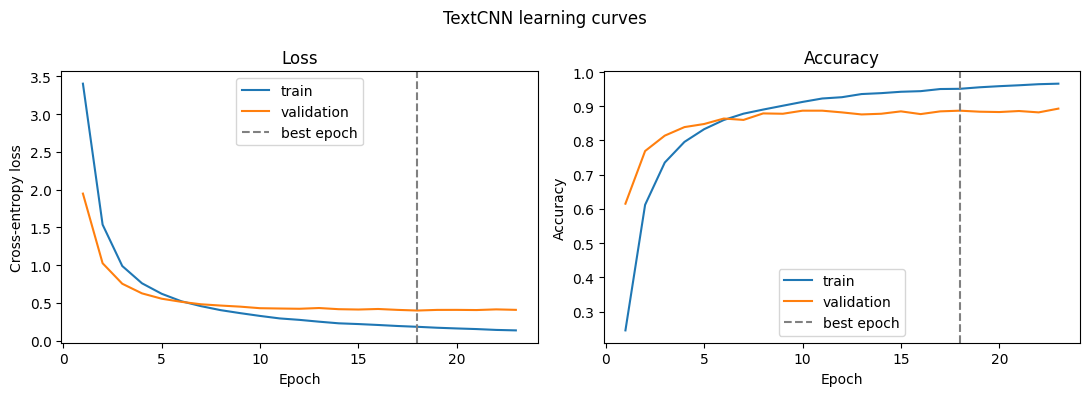


Best epoch: 18 | val loss 0.3976 | val acc 0.8871
Training time: 39.9 sec


In [5]:
import copy, json, random, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

CONFIG = {
    "seed": 42,
    "max_len": 50,
    "embed_dim": 100,
    "kernel_sizes": [2, 3, 4],
    "num_filters": 100,
    "dropout": 0.5,
    "freeze_embeddings": False,
    "batch_size": 64,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "max_epochs": 30,
    "patience": 5,
}
RESULTS_DIR = Path("results_textcnn")


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_loader(X, y, batch_size, shuffle):
    dataset = TensorDataset(X, torch.tensor(y, dtype=torch.long))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def run_epoch(model, loader, loss_fn, device, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, count = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            scores = model(xb)
            loss = loss_fn(scores, yb)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct += (scores.argmax(dim=1) == yb).sum().item()
            count += len(yb)
    return total_loss / count, correct / count


def train_model(model, train_loader, val_loader, config, device):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"]
    )
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss, best_state, best_epoch, bad_epochs = float("inf"), None, 0, 0

    start = time.time()
    for epoch in range(1, config["max_epochs"] + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, loss_fn, device, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, loss_fn, device)
        for k, v in zip(history, (tr_loss, tr_acc, va_loss, va_acc)):
            history[k].append(v)
        print(f"Epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} "
              f"| val loss {va_loss:.4f} acc {va_acc:.4f}")

        if va_loss < best_val_loss:
            best_val_loss, best_epoch, bad_epochs = va_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1
            if bad_epochs >= config["patience"]:
                print(f"Early stopping at epoch {epoch} (best epoch was {best_epoch})")
                break

    history["train_time_sec"] = time.time() - start
    history["best_epoch"] = best_epoch
    model.load_state_dict(best_state)
    return model, history


def plot_history(history, path):
    import matplotlib.pyplot as plt
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(epochs, history["train_loss"], label="train")
    ax[0].plot(epochs, history["val_loss"], label="validation")
    ax[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy loss")
    ax[1].plot(epochs, history["train_acc"], label="train")
    ax[1].plot(epochs, history["val_acc"], label="validation")
    ax[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    for a in ax:
        a.axvline(history["best_epoch"], color="grey", linestyle="--", label="best epoch")
        a.legend()
    fig.suptitle("TextCNN learning curves")
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()


# ---- run it ----
config = CONFIG
set_seed(config["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

vocab = build_vocab(train["text"].tolist())
X_train = encode_batch(train["text"], vocab, config["max_len"])
X_val = encode_batch(val["text"], vocab, config["max_len"])
matrix, _ = build_embedding_matrix(vocab)

train_loader = make_loader(X_train, train["label"].values, config["batch_size"], shuffle=True)
val_loader = make_loader(X_val, val["label"].values, config["batch_size"], shuffle=False)

model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=config["embed_dim"],
    num_classes=77,
    kernel_sizes=tuple(config["kernel_sizes"]),
    num_filters=config["num_filters"],
    dropout=config["dropout"],
    pretrained=matrix,
    freeze_embeddings=config["freeze_embeddings"],
).to(device)
print(f"Trainable parameters: {count_parameters(model):,}\n")

model, history = train_model(model, train_loader, val_loader, config, device)

RESULTS_DIR.mkdir(exist_ok=True)
torch.save(model.state_dict(), "best_model.pt")
json.dump(history, open(RESULTS_DIR / "history.json", "w"), indent=2)
json.dump(config, open(RESULTS_DIR / "config.json", "w"), indent=2)
plot_history(history, RESULTS_DIR / "learning_curves.png")

best = history["best_epoch"] - 1
print(f"\nBest epoch: {history['best_epoch']} | val loss {history['val_loss'][best]:.4f} "
      f"| val acc {history['val_acc'][best]:.4f}")
print(f"Training time: {history['train_time_sec']:.1f} sec")

test_accuracy                0.9084
macro_precision              0.9133
macro_recall                 0.9084
macro_f1                     0.9086
weighted_f1                  0.9086
roc_auc_ovr_macro            0.9988
parameters                   258977
train_time_sec               39.8544
best_epoch                   18
inference_time_total_sec     0.1011
inference_ms_per_sentence    0.0328
device                       cuda:0
num_test_sentences           3080


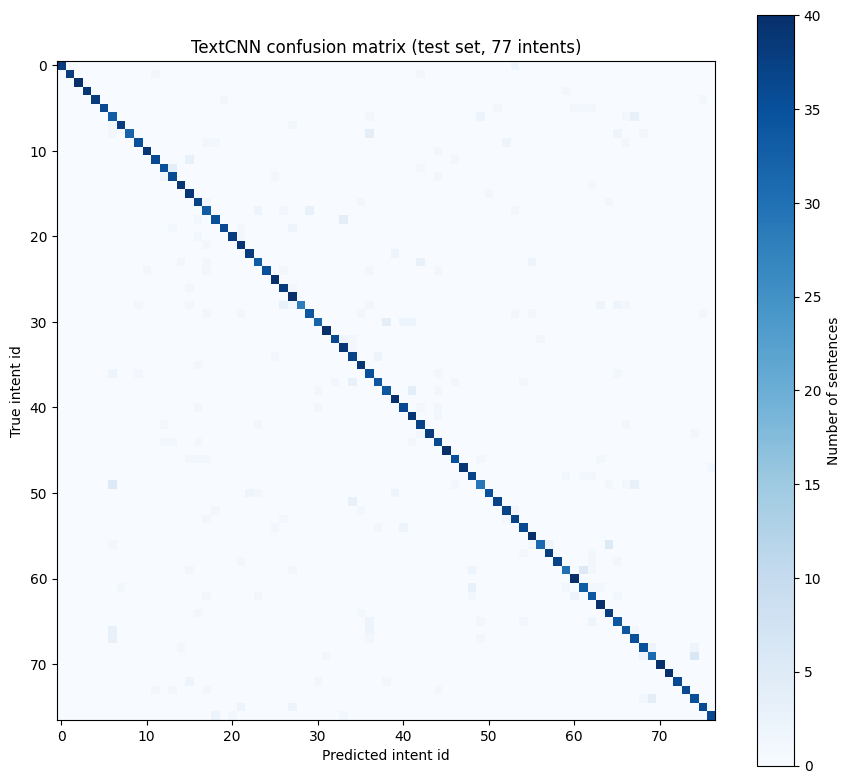


Top 10 confusions (true -> predicted, count):
  verify_my_identity -> why_verify_identity: 6
  pending_transfer -> balance_not_updated_after_bank_transfer: 5
  top_up_by_bank_transfer_charge -> transfer_fee_charged: 5
  top_up_failed -> top_up_reverted: 5
  beneficiary_not_allowed -> failed_transfer: 4
  card_arrival -> card_delivery_estimate: 4
  card_payment_wrong_exchange_rate -> exchange_rate: 4
  disposable_card_limits -> get_disposable_virtual_card: 4
  get_disposable_virtual_card -> getting_virtual_card: 4
  why_verify_identity -> verify_my_identity: 4

Misclassified: 282 of 3080 sentences


In [6]:
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)

from pathlib import Path
labels = json.load(open(Path("/content") / "labels.json"))
device = next(model.parameters()).device


def predict(model, X, device, batch_size=64):
    model.eval()
    outputs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            scores = model(X[i:i + batch_size].to(device))
            outputs.append(torch.softmax(scores, dim=1).cpu())
    return torch.cat(outputs).numpy()


# ---- test data (vocabulary comes from TRAIN only) ----
vocab = build_vocab(train["text"].tolist())
X_test = encode_batch(test["text"], vocab, config["max_len"])
y_test = test["label"].values

# ---- predict, and time it ----
predict(model, X_test[:64], device)          # warm-up, not timed
start = time.time()
probs = predict(model, X_test, device)
inference_sec = time.time() - start
y_pred = probs.argmax(axis=1)

# ---- metrics ----
acc = accuracy_score(y_test, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
_, _, weighted_f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro")

metrics = {
    "test_accuracy": acc,
    "macro_precision": p,
    "macro_recall": r,
    "macro_f1": f1,
    "weighted_f1": weighted_f1,
    "roc_auc_ovr_macro": auc,
    "parameters": count_parameters(model),
    "train_time_sec": history["train_time_sec"],
    "best_epoch": history["best_epoch"],
    "inference_time_total_sec": inference_sec,
    "inference_ms_per_sentence": 1000 * inference_sec / len(X_test),
    "device": str(device),
    "num_test_sentences": int(len(X_test)),
}
for k, v in metrics.items():
    print(f"{k:28s} {v:.4f}" if isinstance(v, float) else f"{k:28s} {v}")

RESULTS_DIR.mkdir(exist_ok=True)
json.dump(metrics, open(RESULTS_DIR / "test_metrics.json", "w"), indent=2)

# ---- per-class report ----
report = classification_report(y_test, y_pred, target_names=labels, output_dict=True, zero_division=0)
pd.DataFrame(report).T.to_csv(RESULTS_DIR / "per_class_report.csv")

# ---- confusion matrix ----
cm = confusion_matrix(y_test, y_pred, labels=range(len(labels)))
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set(title="TextCNN confusion matrix (test set, 77 intents)",
       xlabel="Predicted intent id", ylabel="True intent id")
fig.colorbar(im, ax=ax, label="Number of sentences")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# ---- most common mistakes ----
pairs = [(labels[i], labels[j], int(cm[i, j]))
         for i in range(len(labels)) for j in range(len(labels)) if i != j and cm[i, j] > 0]
pairs.sort(key=lambda t: -t[2])
pd.DataFrame(pairs, columns=["true_intent", "predicted_intent", "count"]).to_csv(
    RESULTS_DIR / "top_confusions.csv", index=False)

wrong = test.assign(predicted=[labels[i] for i in y_pred], confidence=probs.max(axis=1))
wrong = wrong[y_pred != y_test][["text", "category", "predicted", "confidence"]]
wrong.to_csv(RESULTS_DIR / "misclassified_examples.csv", index=False)

print("\nTop 10 confusions (true -> predicted, count):")
for t, pr, c in pairs[:10]:
    print(f"  {t} -> {pr}: {c}")
print(f"\nMisclassified: {len(wrong)} of {len(test)} sentences")

In [7]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, classification_report
)


def compute_metrics(y_true, y_pred, y_probs=None) -> dict:
    """
    Compute the standard metric set for a multi-class classifier.

    y_true, y_pred: 1D arrays of integer label ids
    y_probs: optional 2D array (n_samples, n_classes) of predicted
             probabilities, needed for ROC-AUC. If not provided,
             roc_auc is omitted.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    metrics = {
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }

    if y_probs is not None:
        y_probs = np.asarray(y_probs)
        metrics["macro_roc_auc"] = float(
            roc_auc_score(y_true, y_probs, multi_class="ovr", average="macro")
        )

    return metrics


def save_metrics(metrics: dict, path: Path):
    with open(path, "w") as f:
        json.dump(metrics, f, indent=2)


def save_classification_report(y_true, y_pred, label_names, path: Path):
    report = classification_report(y_true, y_pred, target_names=label_names, zero_division=0)
    with open(path, "w") as f:
        f.write(report)
    return report


def plot_confusion_matrix(y_true, y_pred, label_names, title: str, save_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(20, 18))
    sns.heatmap(cm, cmap="Blues", ax=ax, cbar=True, square=True,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} \u2014 Accuracy {accuracy:.2%}")
    plt.xticks(rotation=90, fontsize=5)
    plt.yticks(rotation=0, fontsize=5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

    return cm


def print_and_save_top_confusions(cm, label_names, save_path: Path, top_n: int = 15):
    """
    Find the most common mistakes: (true intent, predicted intent, count) triples,
    ignoring the diagonal (correct predictions).
    """
    confusions = []
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            if i != j and cm[i, j] > 0:
                confusions.append((cm[i, j], label_names[i], label_names[j]))

    confusions.sort(reverse=True)

    print(f"\n{'='*70}")
    print(f"TOP {top_n} MOST CONFUSED PAIRS (true \u2192 predicted)")
    print(f"{'='*70}")
    lines = [f"{'count':>5}  {'true intent':<45} -> predicted intent"]
    for count, true_label, pred_label in confusions[:top_n]:
        line = f"{count:>5}  {true_label:<45} -> {pred_label}"
        print(line)
        lines.append(line)

    with open(save_path, "w") as f:
        f.write("\n".join(lines))
    print(f"\nSaved: {save_path}")

    return confusions

accuracy                     0.9084
macro_precision              0.9133
macro_recall                 0.9084
macro_f1                     0.9086
macro_roc_auc                0.9988
parameters                   258977
train_time_sec               39.8544
best_epoch                   18
inference_time_total_sec     0.0467
inference_ms_per_sentence    0.0152
device                       cuda:0


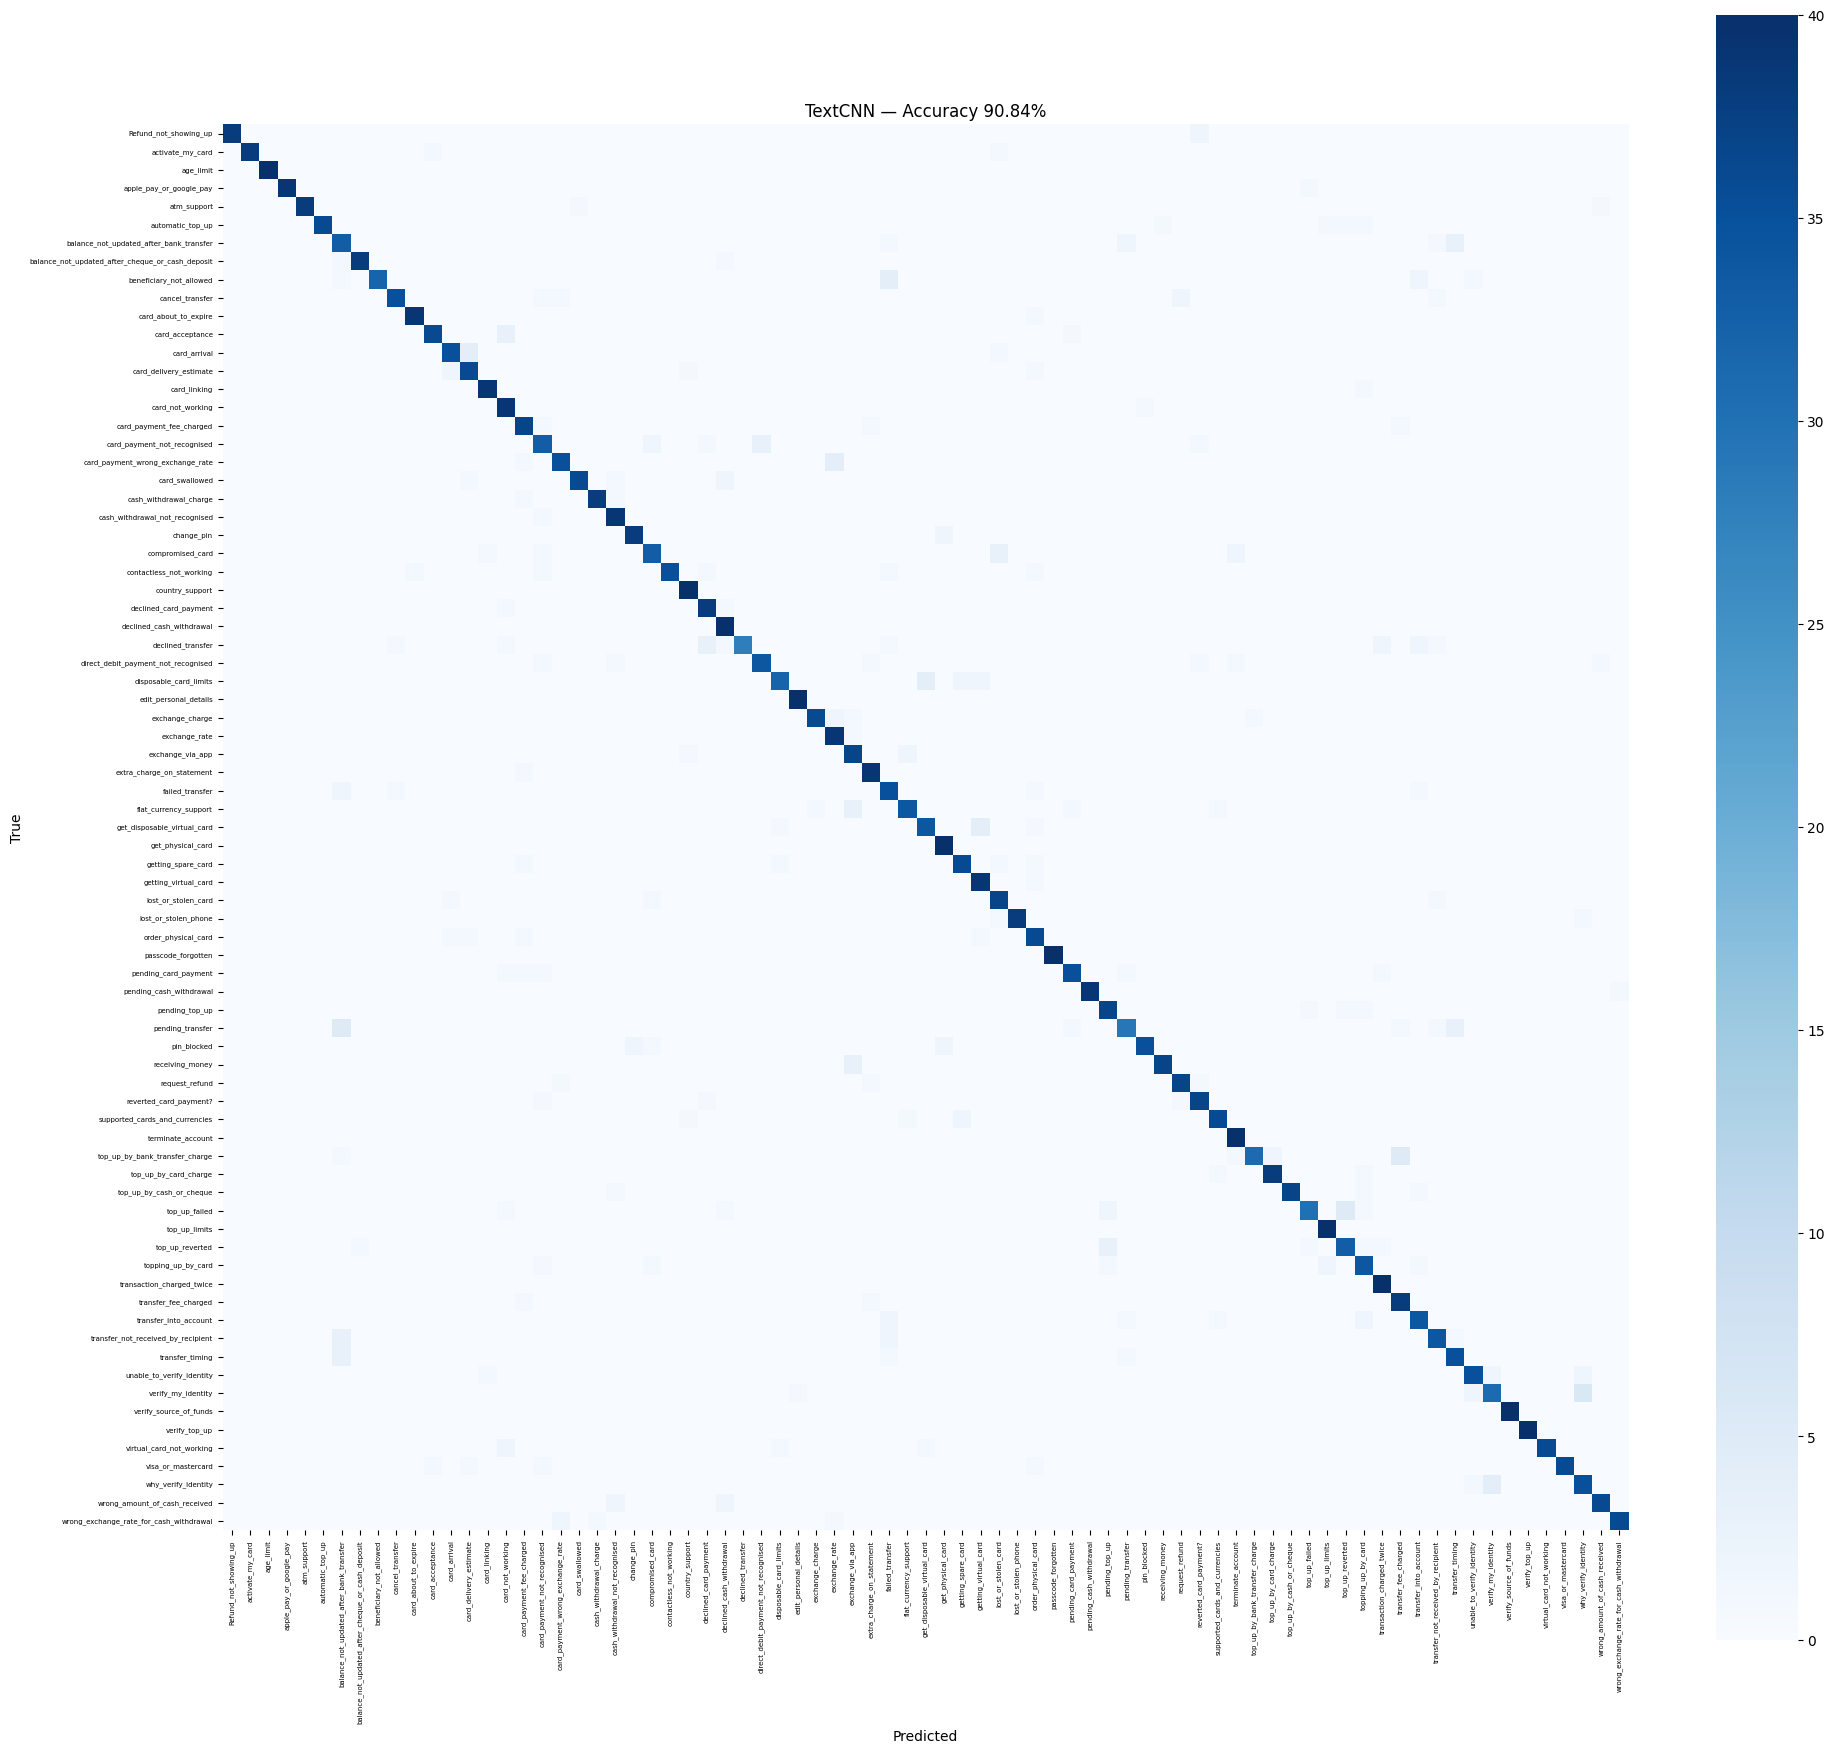


TOP 15 MOST CONFUSED PAIRS (true → predicted)
    6  verify_my_identity                            -> why_verify_identity
    5  top_up_failed                                 -> top_up_reverted
    5  top_up_by_bank_transfer_charge                -> transfer_fee_charged
    5  pending_transfer                              -> balance_not_updated_after_bank_transfer
    4  why_verify_identity                           -> verify_my_identity
    4  get_disposable_virtual_card                   -> getting_virtual_card
    4  disposable_card_limits                        -> get_disposable_virtual_card
    4  card_payment_wrong_exchange_rate              -> exchange_rate
    4  card_arrival                                  -> card_delivery_estimate
    4  beneficiary_not_allowed                       -> failed_transfer
    3  transfer_timing                               -> balance_not_updated_after_bank_transfer
    3  transfer_not_received_by_recipient            -> balance_not_updated_aft

[(np.int64(6), 'verify_my_identity', 'why_verify_identity'),
 (np.int64(5), 'top_up_failed', 'top_up_reverted'),
 (np.int64(5), 'top_up_by_bank_transfer_charge', 'transfer_fee_charged'),
 (np.int64(5), 'pending_transfer', 'balance_not_updated_after_bank_transfer'),
 (np.int64(4), 'why_verify_identity', 'verify_my_identity'),
 (np.int64(4), 'get_disposable_virtual_card', 'getting_virtual_card'),
 (np.int64(4), 'disposable_card_limits', 'get_disposable_virtual_card'),
 (np.int64(4), 'card_payment_wrong_exchange_rate', 'exchange_rate'),
 (np.int64(4), 'card_arrival', 'card_delivery_estimate'),
 (np.int64(4), 'beneficiary_not_allowed', 'failed_transfer'),
 (np.int64(3), 'transfer_timing', 'balance_not_updated_after_bank_transfer'),
 (np.int64(3),
  'transfer_not_received_by_recipient',
  'balance_not_updated_after_bank_transfer'),
 (np.int64(3), 'top_up_reverted', 'pending_top_up'),
 (np.int64(3), 'receiving_money', 'exchange_via_app'),
 (np.int64(3), 'pending_transfer', 'transfer_timing')

In [8]:
import json, time
import numpy as np
import pandas as pd
from pathlib import Path

labels = json.load(open(Path("/content") / "labels.json"))
device = next(model.parameters()).device


def predict(model, X, device, batch_size=64):
    model.eval()
    outputs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            scores = model(X[i:i + batch_size].to(device))
            outputs.append(torch.softmax(scores, dim=1).cpu())
    return torch.cat(outputs).numpy()


vocab = build_vocab(train["text"].tolist())
X_test = encode_batch(test["text"], vocab, config["max_len"])
y_test = test["label"].values

predict(model, X_test[:64], device)          # warm-up
start = time.time()
probs = predict(model, X_test, device)
inference_sec = time.time() - start
y_pred = probs.argmax(axis=1)

metrics = compute_metrics(y_test, y_pred, probs)
metrics.update({
    "parameters": count_parameters(model),
    "train_time_sec": history["train_time_sec"],
    "best_epoch": history["best_epoch"],
    "inference_time_total_sec": inference_sec,
    "inference_ms_per_sentence": 1000 * inference_sec / len(X_test),
    "device": str(device),
})
for k, v in metrics.items():
    print(f"{k:28s} {v:.4f}" if isinstance(v, float) else f"{k:28s} {v}")

RESULTS_DIR.mkdir(exist_ok=True)
save_metrics(metrics, RESULTS_DIR / "test_metrics.json")
save_classification_report(y_test, y_pred, labels, RESULTS_DIR / "per_class_report.txt")
cm = plot_confusion_matrix(y_test, y_pred, labels, "TextCNN", RESULTS_DIR / "confusion_matrix.png")
print_and_save_top_confusions(cm, labels, RESULTS_DIR / "top_confusions.txt")

In [9]:
import contextlib, io
import pandas as pd
import matplotlib.pyplot as plt

EXPERIMENTS = [
    ("baseline (seed 42)", {}, 42, True),
    ("baseline (seed 43)", {}, 43, True),
    ("baseline (seed 44)", {}, 44, True),
    ("embeddings frozen", {"freeze_embeddings": True}, 42, True),
    ("embeddings random (no GloVe)", {}, 42, False),
    ("dropout 0.3", {"dropout": 0.3}, 42, True),
    ("dropout 0.7", {"dropout": 0.7}, 42, True),
    ("kernels 3,4,5", {"kernel_sizes": [3, 4, 5]}, 42, True),
    ("kernels 1,2,3", {"kernel_sizes": [1, 2, 3]}, 42, True),
    ("kernel 3 only", {"kernel_sizes": [3]}, 42, True),
    ("filters 50", {"num_filters": 50}, 42, True),
    ("filters 200", {"num_filters": 200}, 42, True),
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab = build_vocab(train["text"].tolist())
matrix, _ = build_embedding_matrix(vocab)
X_tr = encode_batch(train["text"], vocab, CONFIG["max_len"])
X_va = encode_batch(val["text"], vocab, CONFIG["max_len"])

rows = []
for name, changes, seed, use_glove in EXPERIMENTS:
    cfg = {**CONFIG, **changes, "seed": seed}
    set_seed(seed)
    tr_loader = make_loader(X_tr, train["label"].values, cfg["batch_size"], True)
    va_loader = make_loader(X_va, val["label"].values, cfg["batch_size"], False)
    m = TextCNN(len(vocab), cfg["embed_dim"], 77, tuple(cfg["kernel_sizes"]),
                cfg["num_filters"], cfg["dropout"],
                pretrained=matrix if use_glove else None,
                freeze_embeddings=cfg["freeze_embeddings"]).to(device)
    with contextlib.redirect_stdout(io.StringIO()):
        m, h = train_model(m, tr_loader, va_loader, cfg, device)
    b = h["best_epoch"] - 1
    rows.append({"experiment": name, "val_acc": h["val_acc"][b], "val_loss": h["val_loss"][b],
                 "overfit_gap": h["train_acc"][b] - h["val_acc"][b],
                 "best_epoch": h["best_epoch"], "parameters": count_parameters(m),
                 "train_time_sec": h["train_time_sec"]})
    print(f"{name:32s} val acc {rows[-1]['val_acc']:.4f} | gap {rows[-1]['overfit_gap']:.3f} "
          f"| params {rows[-1]['parameters']:,} | {rows[-1]['train_time_sec']:.0f}s")

df = pd.DataFrame(rows)
base = df[df["experiment"].str.startswith("baseline")]["val_acc"]
print(f"\nBaseline over 3 seeds: mean {base.mean():.4f}, min {base.min():.4f}, max {base.max():.4f}")
df

baseline (seed 42)               val acc 0.8891 | gap 0.062 | params 258,977 | 40s
baseline (seed 43)               val acc 0.8981 | gap 0.068 | params 258,977 | 51s
baseline (seed 44)               val acc 0.9011 | gap 0.066 | params 258,977 | 50s
embeddings frozen                val acc 0.8931 | gap 0.030 | params 113,477 | 39s
embeddings random (no GloVe)     val acc 0.8731 | gap 0.096 | params 258,977 | 53s
dropout 0.3                      val acc 0.8881 | gap 0.091 | params 258,977 | 43s
dropout 0.7                      val acc 0.9011 | gap 0.032 | params 258,977 | 53s
kernels 3,4,5                    val acc 0.8921 | gap 0.069 | params 288,977 | 79s
kernels 1,2,3                    val acc 0.8921 | gap 0.062 | params 228,977 | 14s
kernel 3 only                    val acc 0.8941 | gap 0.032 | params 183,377 | 12s
filters 50                       val acc 0.8901 | gap 0.057 | params 202,277 | 35s
filters 200                      val acc 0.8921 | gap 0.069 | params 372,377 | 11s

Bas

,experiment,val_acc,val_loss,overfit_gap,best_epoch,parameters,train_time_sec
0,baseline (seed 42),0.889111,0.397324,0.062455,18,258977,39.526232
1,baseline (seed 43),0.898102,0.370608,0.068461,24,258977,51.185963
2,baseline (seed 44),0.901099,0.379979,0.066020,23,258977,49.937173
3,embeddings frozen,0.893107,0.411562,0.030021,18,113477,39.321241
4,embeddings random (no GloVe),0.873127,0.440050,0.096324,30,258977,53.400867
5,dropout 0.3,0.888112,0.396180,0.091226,19,258977,42.874557
6,dropout 0.7,0.901099,0.376789,0.032360,28,258977,52.985963
7,"kernels 3,4,5",0.892108,0.379433,0.068790,20,288977,79.159016
8,"kernels 1,2,3",0.892108,0.371269,0.061791,21,228977,13.501270
9,kernel 3 only,0.894106,0.410082,0.031688,30,183377,11.625861
